PHASE 0 — Setup & Reproducibility

In [68]:
# Install dependencies (safe for Colab)
!pip install torch torchvision matplotlib -q

# Core imports
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

print("Environment ready ✅")

Environment ready ✅


In [69]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


In [70]:
CONFIG = {
    "batch_size": 128,
    "learning_rate": 1e-3,
    "epochs": 20,  # slightly increased for better convergence
    "lambda": 0.01  # default, will change in experiments
}

print(CONFIG)

{'batch_size': 128, 'learning_rate': 0.001, 'epochs': 20, 'lambda': 0.01}


PHASE 1 — Data Pipeline

In [71]:
# Normalize + Flatten (for MLP)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
    transforms.Lambda(lambda x: x.view(-1))  # flatten to 3072
])

print("Transforms ready ✅")

Transforms ready ✅


In [72]:
#Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 50000
Test size: 10000


In [73]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False
)

print("DataLoaders ready ✅")

DataLoaders ready ✅


In [74]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Sample labels:", labels[:10])

Image shape: torch.Size([128, 3072])
Label shape: torch.Size([128])
Sample labels: tensor([6, 0, 4, 1, 2, 7, 9, 4, 7, 8])


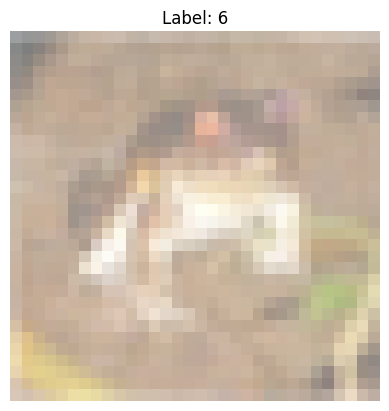

In [75]:
# Visualize raw image (before flattening)
raw_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

img, label = raw_dataset[0]

# Unnormalize for display
img = img / 2 + 0.5
npimg = img.numpy()

plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

PHASE 2 — Model (Prunable Network)

In [76]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, temperature=0.5):
        super(PrunableLinear, self).__init__()

        # Standard parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        #  Improved gate initialization (critical)
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features) - 2.0
        )

        #  Temperature for sharper gating
        self.temperature = temperature

    def forward(self, x):
        # Convert scores → gates
        temperature = 0.3  # override or reduce from 0.5
        gates = torch.sigmoid(self.gate_scores / temperature)

        # Apply pruning
        pruned_weights = self.weight * gates

        # Linear operation
        output = torch.matmul(x, pruned_weights.t()) + self.bias

        return output

In [77]:
layer = PrunableLinear(3072, 512)

x = torch.randn(4, 3072)
out = layer(x)

print("Input:", x.shape)
print("Output:", out.shape)

Input: torch.Size([4, 3072])
Output: torch.Size([4, 512])


In [78]:
# inspect gates
with torch.no_grad():
    gates = torch.sigmoid(layer.gate_scores / layer.temperature)

print("Gate stats:")
print("Min:", gates.min().item())
print("Max:", gates.max().item())
print("Mean:", gates.mean().item())

Gate stats:
Min: 1.6302282119795564e-06
Max: 0.9952070116996765
Mean: 0.06752070039510727


In [79]:
# Build Full Network
class PrunableMLP(nn.Module):
    def __init__(self):
        super(PrunableMLP, self).__init__()

        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [80]:
# Gate Extraction Utility
def get_all_gates(model):
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores / module.temperature)
            all_gates.append(gates.view(-1))

    return torch.cat(all_gates)

In [81]:
# Instantiate Model
model = PrunableMLP().to(device)

print(model)

PrunableMLP(
  (fc1): PrunableLinear()
  (fc2): PrunableLinear()
  (fc3): PrunableLinear()
  (relu): ReLU()
)


In [82]:
images, labels = next(iter(train_loader))
images = images.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)

Output shape: torch.Size([128, 10])


PHASE 3 — Loss Design

In [83]:
# Multi class classification loss
criterion = nn.CrossEntropyLoss()

print("CrossEntropy Loss ready ")

CrossEntropy Loss ready ✅


In [84]:
# Sparsity Loss
def compute_sparsity_loss(model):
    gates = get_all_gates(model)

    # L1 sparsity (strong push to zero)
    sparsity_loss = torch.mean(torch.abs(gates)) * 1.5

    return sparsity_loss

In [85]:
def compute_total_loss(model, outputs, labels, lambda_val):

    # Classification loss
    ce_loss = criterion(outputs, labels)

    # Sparsity loss
    sparsity_loss = compute_sparsity_loss(model)

    # Combined loss
    total_loss = ce_loss + lambda_val * sparsity_loss

    return total_loss, ce_loss, sparsity_loss

In [86]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)

total_loss, ce_loss, sparsity_loss = compute_total_loss(
    model, outputs, labels, CONFIG["lambda"]
)

print(f"CE Loss: {ce_loss.item():.4f}")
print(f"Sparsity Loss: {sparsity_loss.item():.4f}")
print(f"Total Loss: {total_loss.item():.4f}")

CE Loss: 2.3026
Sparsity Loss: 0.1016
Total Loss: 2.3036


In [87]:
# Gradient Flow Check
model.zero_grad()
total_loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad mean = {param.grad.abs().mean().item():.6f}")

fc1.weight: grad mean = 0.000000
fc1.bias: grad mean = 0.000001
fc1.gate_scores: grad mean = 0.000000
fc2.weight: grad mean = 0.000000
fc2.bias: grad mean = 0.000033
fc2.gate_scores: grad mean = 0.000000
fc3.weight: grad mean = 0.000000
fc3.bias: grad mean = 0.022188
fc3.gate_scores: grad mean = 0.000000


PHASE 4 — Training Engine

In [88]:
# Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
print("Optimizer ready ")

Optimizer ready ✅


In [89]:
# train one epoch
def train_one_epoch(model, train_loader, optimizer, lambda_val):
    model.train()

    total_loss_sum = 0.0
    ce_loss_sum = 0.0
    sparsity_loss_sum = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)

        # Loss
        total_loss, ce_loss, sparsity_loss = compute_total_loss(
            model, outputs, labels, lambda_val
        )

        # Backward
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Accumulate
        total_loss_sum += total_loss.item()
        ce_loss_sum += ce_loss.item()
        sparsity_loss_sum += sparsity_loss.item()

    n = len(train_loader)
    return {
        "total_loss": total_loss_sum / n,
        "ce_loss": ce_loss_sum / n,
        "sparsity_loss": sparsity_loss_sum / n
    }

In [90]:
def get_lambda(epoch, total_epochs, base_lambda):
    return base_lambda * (epoch / total_epochs)

In [91]:
# Full Training Loop
def train_model(model, train_loader, optimizer, config):

    history = {
        "total_loss": [],
        "ce_loss": [],
        "sparsity_loss": []
    }

    for epoch in range(config["epochs"]):
        current_lambda = get_lambda(epoch, config["epochs"], config["lambda"])

        stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            current_lambda
        )


        history["total_loss"].append(stats["total_loss"])
        history["ce_loss"].append(stats["ce_loss"])
        history["sparsity_loss"].append(stats["sparsity_loss"])

        print(f"\nEpoch [{epoch+1}/{config['epochs']}]")
        print(f"  Total Loss: {stats['total_loss']:.4f}")
        print(f"  CE Loss: {stats['ce_loss']:.4f}")
        print(f"  Sparsity Loss: {stats['sparsity_loss']:.4f}")

    return history

In [92]:
# train the model
model = PrunableMLP().to(device)

optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

history = train_model(model, train_loader, optimizer, CONFIG)


Epoch [1/20]
  Total Loss: 1.9245
  CE Loss: 1.9245
  Sparsity Loss: 0.1072

Epoch [2/20]
  Total Loss: 1.6207
  CE Loss: 1.6206
  Sparsity Loss: 0.1105

Epoch [3/20]
  Total Loss: 1.5210
  CE Loss: 1.5209
  Sparsity Loss: 0.1112

Epoch [4/20]
  Total Loss: 1.4524
  CE Loss: 1.4522
  Sparsity Loss: 0.1116

Epoch [5/20]
  Total Loss: 1.3934
  CE Loss: 1.3932
  Sparsity Loss: 0.1119

Epoch [6/20]
  Total Loss: 1.3404
  CE Loss: 1.3401
  Sparsity Loss: 0.1120

Epoch [7/20]
  Total Loss: 1.2910
  CE Loss: 1.2906
  Sparsity Loss: 0.1122

Epoch [8/20]
  Total Loss: 1.2441
  CE Loss: 1.2437
  Sparsity Loss: 0.1122

Epoch [9/20]
  Total Loss: 1.2009
  CE Loss: 1.2005
  Sparsity Loss: 0.1123

Epoch [10/20]
  Total Loss: 1.1620
  CE Loss: 1.1615
  Sparsity Loss: 0.1123

Epoch [11/20]
  Total Loss: 1.1253
  CE Loss: 1.1247
  Sparsity Loss: 0.1123

Epoch [12/20]
  Total Loss: 1.0898
  CE Loss: 1.0892
  Sparsity Loss: 0.1123

Epoch [13/20]
  Total Loss: 1.0585
  CE Loss: 1.0578
  Sparsity Loss: 0.

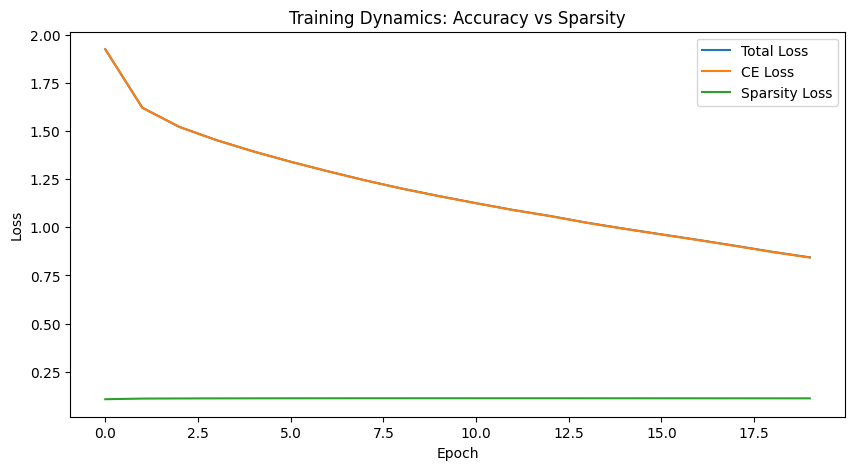

In [93]:
# Plot Training Dynamics
plt.figure(figsize=(10,5))

plt.plot(history["total_loss"], label="Total Loss")
plt.plot(history["ce_loss"], label="CE Loss")
plt.plot(history["sparsity_loss"], label="Sparsity Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Dynamics: Accuracy vs Sparsity")
plt.legend()
plt.show()

PHASE 5 — Evaluation

In [94]:
def evaluate_accuracy(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [95]:
def calculate_sparsity(model, threshold=1e-2):
    gates = get_all_gates(model)

    pruned = (gates < threshold).sum().item()
    total = gates.numel()

    return 100 * pruned / total

In [96]:
acc = evaluate_accuracy(model, test_loader)
sparsity = calculate_sparsity(model)

print(f"Accuracy: {acc:.2f}%")
print(f"Sparsity: {sparsity:.2f}%")

Accuracy: 53.90%
Sparsity: 37.66%


In [97]:
lambda_values = [0.01, 0.1, 0.5, 1.0, 2.0]

In [98]:
# Experiment Function
def run_experiment(lambda_val):
    print(f"\nRunning λ = {lambda_val}")

    # fresh model
    model = PrunableMLP().to(device)

    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

    config = CONFIG.copy()
    config["lambda"] = lambda_val

    # train
    train_model(model, train_loader, optimizer, config)

    # evaluate
    acc = evaluate_accuracy(model, test_loader)
    sparsity = calculate_sparsity(model)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    return {
        "lambda": lambda_val,
        "accuracy": acc,
        "sparsity": sparsity,
        "model": model
    }

In [99]:
# Run All Experiments
results = []

for lam in lambda_values:
    result = run_experiment(lam)
    results.append(result)


Running λ = 0.01

Epoch [1/20]
  Total Loss: 1.9405
  CE Loss: 1.9405
  Sparsity Loss: 0.1069

Epoch [2/20]
  Total Loss: 1.6309
  CE Loss: 1.6308
  Sparsity Loss: 0.1102

Epoch [3/20]
  Total Loss: 1.5243
  CE Loss: 1.5242
  Sparsity Loss: 0.1109

Epoch [4/20]
  Total Loss: 1.4534
  CE Loss: 1.4532
  Sparsity Loss: 0.1113

Epoch [5/20]
  Total Loss: 1.3951
  CE Loss: 1.3948
  Sparsity Loss: 0.1115

Epoch [6/20]
  Total Loss: 1.3433
  CE Loss: 1.3430
  Sparsity Loss: 0.1117

Epoch [7/20]
  Total Loss: 1.2976
  CE Loss: 1.2973
  Sparsity Loss: 0.1118

Epoch [8/20]
  Total Loss: 1.2550
  CE Loss: 1.2546
  Sparsity Loss: 0.1118

Epoch [9/20]
  Total Loss: 1.2131
  CE Loss: 1.2127
  Sparsity Loss: 0.1119

Epoch [10/20]
  Total Loss: 1.1769
  CE Loss: 1.1764
  Sparsity Loss: 0.1118

Epoch [11/20]
  Total Loss: 1.1416
  CE Loss: 1.1410
  Sparsity Loss: 0.1118

Epoch [12/20]
  Total Loss: 1.1068
  CE Loss: 1.1062
  Sparsity Loss: 0.1118

Epoch [13/20]
  Total Loss: 1.0730
  CE Loss: 1.0724
 

In [100]:
#Results Table
print("\nFinal Results:\n")
print("Lambda\tAccuracy\tSparsity")

for r in results:
    print(f"{r['lambda']}\t{r['accuracy']:.2f}%\t\t{r['sparsity']:.2f}%")


Final Results:

Lambda	Accuracy	Sparsity
0.01	53.70%		37.71%
0.1	53.59%		40.58%
0.5	53.61%		48.39%
1.0	53.95%		54.76%
2.0	53.09%		62.02%


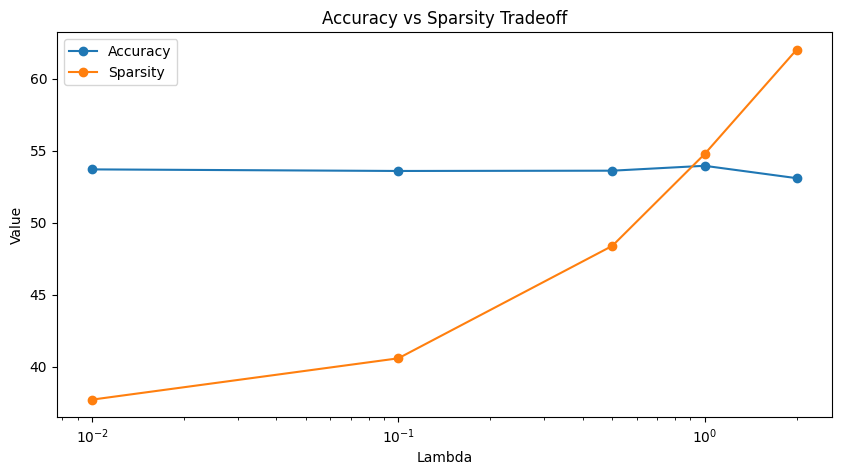

In [101]:
#Tradeoff Plot
lambdas = [r["lambda"] for r in results]
accuracies = [r["accuracy"] for r in results]
sparsities = [r["sparsity"] for r in results]

plt.figure(figsize=(10,5))

plt.plot(lambdas, accuracies, marker='o', label="Accuracy")
plt.plot(lambdas, sparsities, marker='o', label="Sparsity")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Value")
plt.title("Accuracy vs Sparsity Tradeoff")
plt.legend()
plt.show()

In [102]:
# Gate Distribution
best_model = results[2]["model"]

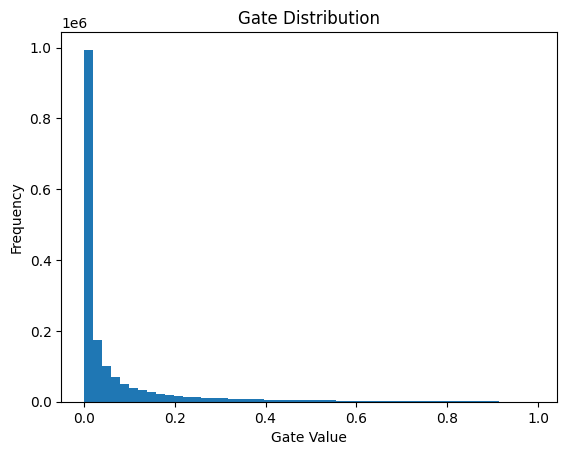

In [103]:
gates = get_all_gates(best_model).cpu().detach().numpy()

plt.hist(gates, bins=50)
plt.title("Gate Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

PHASE 7 — Validation & Deep Analysis

In [104]:
# Hard Pruning Validation
def apply_hard_pruning(model, threshold=1e-2):
    pruned = 0
    total = 0

    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores / module.temperature)

                mask = (gates >= threshold).float()

                pruned += (mask == 0).sum().item()
                total += mask.numel()

                # Apply pruning
                module.weight.data *= mask

    return 100 * pruned / total

In [105]:
best_model = results[2]["model"]  # choose λ=0.5 or 1.0

hard_sparsity = apply_hard_pruning(best_model)

acc_after = evaluate_accuracy(best_model, test_loader)

print(f"Hard Sparsity: {hard_sparsity:.2f}%")
print(f"Accuracy after pruning: {acc_after:.2f}%")

Hard Sparsity: 48.39%
Accuracy after pruning: 53.60%


In [106]:
# Layer-wise Sparsity
def layerwise_sparsity(model, threshold=1e-2):
    layer_id = 1

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores / module.temperature)

            pruned = (gates < threshold).sum().item()
            total = gates.numel()

            print(f"Layer {layer_id}: {100 * pruned / total:.2f}% sparsity")
            layer_id += 1

In [107]:
layerwise_sparsity(best_model)

Layer 1: 47.74% sparsity
Layer 2: 56.17% sparsity
Layer 3: 50.66% sparsity


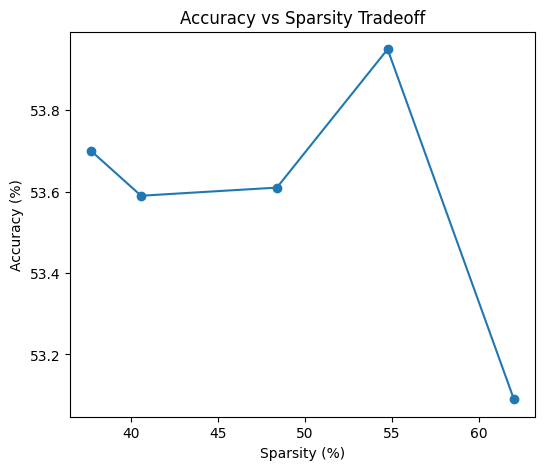

In [110]:
sparsities = [r["sparsity"] for r in results]
accuracies = [r["accuracy"] for r in results]

plt.figure(figsize=(6,5))
plt.plot(sparsities, accuracies, marker='o')
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity Tradeoff")
plt.show()